#### **Library Imports**

In [2]:
from google.colab import userdata

There are 2 types of tokens on HF :
1) READ_token --> we can read anything from HF
2) WRITE_token --> if u want to upload anything to HF

In [3]:
READ_TOKEN = userdata.get('HUGGINGFACE_READ_KEY')

In [4]:
WRITE_TOKEN = userdata.get('HUGGINGFACE_WRITE_KEY')

In [5]:
HF_TOKEN = userdata.get('HF_TOKEN')

In [6]:
#!pip install --upgrade huggingface_hub

In [7]:
from huggingface_hub import HfApi

In [8]:
api=HfApi()

#### **Components of HuggingFaceHub API**

##### **Extracting Repos on HuggingFaceHub**

In [9]:
model_info = api.model_info(repo_id="bert-base-uncased")
## This is used to get the details of the repo mentioned

In [10]:
print("Model Card Metadata:", model_info.card_data)
print("Tags:", model_info.tags)
print("Commit SHA:", model_info.sha)
print("Last Modified:", model_info.last_modified)
print("Files:", [f.rfilename for f in model_info.siblings])
print("Model ID:", model_info.card_data.get('modelId', 'Not available'))
print("Likes:", model_info.likes)
print("Author/Namespace:", model_info.author)
print("Is Private:", model_info.private)
print("Downloads:", model_info.downloads)

Model Card Metadata: datasets:
- bookcorpus
- wikipedia
language: en
license: apache-2.0
tags:
- exbert
Tags: ['transformers', 'pytorch', 'tf', 'jax', 'rust', 'coreml', 'onnx', 'safetensors', 'bert', 'fill-mask', 'exbert', 'en', 'dataset:bookcorpus', 'dataset:wikipedia', 'arxiv:1810.04805', 'license:apache-2.0', 'endpoints_compatible', 'deploy:azure', 'region:us']
Commit SHA: 86b5e0934494bd15c9632b12f734a8a67f723594
Last Modified: 2024-02-19 11:06:12+00:00
Files: ['.gitattributes', 'LICENSE', 'README.md', 'config.json', 'coreml/fill-mask/float32_model.mlpackage/Data/com.apple.CoreML/model.mlmodel', 'coreml/fill-mask/float32_model.mlpackage/Data/com.apple.CoreML/weights/weight.bin', 'coreml/fill-mask/float32_model.mlpackage/Manifest.json', 'flax_model.msgpack', 'model.onnx', 'model.safetensors', 'pytorch_model.bin', 'rust_model.ot', 'tf_model.h5', 'tokenizer.json', 'tokenizer_config.json', 'vocab.txt']
Model ID: Not available
Likes: 2701
Author/Namespace: google-bert
Is Private: False
D

##### **Extracting models names on HuggingFaceHub**

In [11]:
models = api.list_models(search="llama", limit=5)
models
## Gives the different set of models from different repositories provided by Llama

<generator object HfApi.list_models at 0x786af0348200>

In [12]:
for model in models:
  print(model.modelId, "-", model.downloads)

meta-llama/Llama-3.1-8B-Instruct - 8841328
meta-llama/Llama-3.2-3B-Instruct - 2213878
meta-llama/Meta-Llama-3-8B-Instruct - 1416749
meta-llama/Llama-3.1-8B - 1607417
Alittlehammmer/Qwen3.6-27B-DFlash-GGUF-llama.cpp - 7457


In [13]:
qwen_models = api.list_models(search="qwen", limit=5)
qwen_models
## Gives the different set of models from different repositories provided by qwen

<generator object HfApi.list_models at 0x786af03483c0>

In [14]:
for model in qwen_models:
  print(model.modelId, "-", model.downloads)

bottlecapai/ThinkingCap-Qwen3.6-27B - 3699
froggeric/Qwen-Fixed-Chat-Templates - 0
HauhauCS/Qwen3.6-35B-A3B-Uncensored-HauhauCS-Aggressive - 2660170
nvidia/Qwen3.6-27B-NVFP4 - 787748
unsloth/Qwen3.6-27B-MTP-GGUF - 2895457


##### **Extracting Embedding models on HuggingFaceHub**

In [15]:
embed_models = api.list_models(search="embedding", limit=5)
embed_models
## Gives the different set of embedding models from different repositories provided by qwen

<generator object HfApi.list_models at 0x786adfa19000>

In [16]:
for model in embed_models:
  print(model.modelId, "-", model.downloads)

tencent/R3-embedding-0.6b - 193
google/embeddinggemma-300m - 1649049
Qwen/Qwen3-Embedding-0.6B - 11074155
Qwen/Qwen3-Embedding-8B - 2997644
jinaai/jina-embeddings-v5-omni-small - 98635


##### **Extracting repo files on HuggingFaceHub**

In [17]:
from huggingface_hub import list_repo_files

In [18]:
files = list_repo_files("magibu/embeddingmagibu-200m")
print(files)
## gives you the list of files available in a particular repo

['.gitattributes', '1_Pooling/config.json', '2_Dense/config.json', '2_Dense/model.safetensors', '3_Dense/config.json', '3_Dense/model.safetensors', 'README.md', 'chat_template.jinja', 'config.json', 'config_sentence_transformers.json', 'embeddingmagibu-200m.png', 'model.safetensors', 'modules.json', 'sentence_bert_config.json', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer.model', 'tokenizer_config.json']


##### **Extracting data files on HuggingFaceHub**

In [19]:
### You can also get the dataset information
dataset = api.dataset_info("imdb")
print("Files :" , [f.rfilename for f in dataset.siblings])

Files : ['.gitattributes', 'README.md', 'plain_text/test-00000-of-00001.parquet', 'plain_text/train-00000-of-00001.parquet', 'plain_text/unsupervised-00000-of-00001.parquet']


##### **Access HF hosted models via HuggingFaceHub**

In [20]:
##### Access a model from HuggingFace

In [22]:
from huggingface_hub import InferenceClient
client = InferenceClient(
    model = "Qwen/Qwen2.5-7B-Instruct",
    api_key = READ_TOKEN

)
response = client.chat.completions.create(
    messages=[
        {"role": "user", "content": "Explain Hugging Face in simple words"}
    ],
    max_tokens=200
)
print(response.choices[0].message.content)

Sure! Hugging Face is a company and a community that focuses on natural language processing (NLP), which is a part of artificial intelligence that deals with how computers understand and generate human language. Here are some simple points to understand Hugging Face:

1. **Platform for NLP**: Hugging Face provides a platform where researchers, developers, and data scientists can work on NLP tasks. It's like a playground for building and experimenting with language models.

2. **Models and Libraries**: They offer a wide range of pre-trained language models, which are like pre-built tools that can understand and generate text. These models are based on deep learning techniques and are designed to perform various NLP tasks.

3. **Transformers**: Hugging Face is particularly known for its work with transformers, a type of neural network architecture that has revolutionized NLP. They provide easy-to-use libraries and tools to work with these models.

4. **Community and Resources**: The comp

##### **Access HF hosted models via LangChain**

In [ ]:
##### WE CAN DO THE SAME THING USING LANGCHAIN AS WELL

In [57]:
##!pip install langchain-huggingface
##!pip install langchain_community

In [26]:
from langchain_huggingface import ChatHuggingFace
from langchain_huggingface import HuggingFaceEndpoint

llm = HuggingFaceEndpoint(
    repo_id="deepseek-ai/DeepSeek-R1",
    task="text-generation",
    max_new_tokens=512,
    huggingfacehub_api_token=HF_TOKEN
)
chat_model = ChatHuggingFace(llm=llm)
chat_RESP = chat_model.invoke("hello how are you?")

In [27]:
chat_RESP

AIMessage(content='<think>\nHmm, the user just greeted me with "hello how are you?" That\'s a friendly and casual opening. \n\nFirst, I notice they didn\'t capitalize or use punctuation - very informal texting style. Probably wants a quick chat rather than serious help. The double question feels warm though! \n\nI wonder if they\'re just being polite or actually want to know how an AI "feels". Maybe testing if I\'ll give a human-like response? Should keep it light but authentic. \n\nTheir tone seems neutral-positive. No urgency or frustration detected. Since they initiated with small talk, they might want to: \n- Kill time \n- Check if I\'m "awake" \n- Practice English \n- Genuinely seek connection \n\nBest approach: Match their casual vibe but add enthusiasm. Offer clear next steps so they don\'t feel stranded after greetings. The smiley will help signal friendliness since text lacks tone. \n\nImportant to flip the focus back to them quickly - humans usually ask "how are you" to start

In [56]:
from pprint import pprint

pprint(vars(chat_RESP))

{'additional_kwargs': {},
 'content': '<think>\n'
            'Hmm, the user just greeted me with "hello how are you?" That\'s a '
            'friendly and casual opening. \n'
            '\n'
            "First, I notice they didn't capitalize or use punctuation - very "
            'informal texting style. Probably wants a quick chat rather than '
            'serious help. The double question feels warm though! \n'
            '\n'
            "I wonder if they're just being polite or actually want to know "
            'how an AI "feels". Maybe testing if I\'ll give a human-like '
            'response? Should keep it light but authentic. \n'
            '\n'
            'Their tone seems neutral-positive. No urgency or frustration '
            'detected. Since they initiated with small talk, they might want '
            'to: \n'
            '- Kill time \n'
            '- Check if I\'m "awake" \n'
            '- Practice English \n'
            '- Genuinely seek connection \n'


In [43]:
vars(chat_RESP).keys()

dict_keys(['content', 'additional_kwargs', 'response_metadata', 'type', 'name', 'id', 'tool_calls', 'invalid_tool_calls', 'usage_metadata'])

In [55]:
for key in vars(chat_RESP).keys():
  print(f"{key}")
  print(getattr(chat_RESP, key))
  print("."*50)

content
<think>
Hmm, the user just greeted me with "hello how are you?" That's a friendly and casual opening. 

First, I notice they didn't capitalize or use punctuation - very informal texting style. Probably wants a quick chat rather than serious help. The double question feels warm though! 

I wonder if they're just being polite or actually want to know how an AI "feels". Maybe testing if I'll give a human-like response? Should keep it light but authentic. 

Their tone seems neutral-positive. No urgency or frustration detected. Since they initiated with small talk, they might want to: 
- Kill time 
- Check if I'm "awake" 
- Practice English 
- Genuinely seek connection 

Best approach: Match their casual vibe but add enthusiasm. Offer clear next steps so they don't feel stranded after greetings. The smiley will help signal friendliness since text lacks tone. 

Important to flip the focus back to them quickly - humans usually ask "how are you" to start conversation, not get actual st

In [35]:
for key in chat_RESP.response_metadata.keys():
  print(f"{key} : {chat_RESP.response_metadata[key]}")

token_usage : {'completion_tokens': 278, 'prompt_tokens': 8, 'total_tokens': 286}
model_name : deepseek-ai/DeepSeek-R1
system_fingerprint : 
finish_reason : stop
logprobs : None


In [36]:
for key in chat_RESP.usage_metadata.keys():
  print(f"{key} : {chat_RESP.usage_metadata[key]}")

input_tokens : 8
output_tokens : 278
total_tokens : 286


#### **Writing on HuggingFace**

we create fine tuned models in the format of safetensor and keep them in huggingface hub just like keeping the files in github

In [58]:
api = HfApi(token = WRITE_TOKEN)

In [59]:
# Uploading a model in a repo by first creating a repo
api.create_repo(
    repo_id='hmntdhngraedu/hmntrepotest',
    repo_type='model',# default is model only, you may skip
    private=False ## set True for private repos
)

RepoUrl('https://huggingface.co/hmntdhngraedu/hmntrepotest', endpoint='https://huggingface.co', repo_type='model', repo_id='hmntdhngraedu/hmntrepotest')

In [ ]:
import os
os.getcwd()

In [60]:
# Uploading a file
api.upload_file(
    path_or_fileobj='/content/test_file/dataset_info.txt',
    path_in_repo='dataset_info.txt', ## where it goes in repo
    repo_id='hmntdhngraedu/hmntrepotest' ## Same as above
)

CommitInfo(commit_url='https://huggingface.co/hmntdhngraedu/hmntrepotest/commit/5dccb2adc16d8d8bfac4b5613c90d6da720467dd', commit_message='Upload dataset_info.txt with huggingface_hub', commit_description='', oid='5dccb2adc16d8d8bfac4b5613c90d6da720467dd', pr_url=None, repo_url=RepoUrl('https://huggingface.co/hmntdhngraedu/hmntrepotest', endpoint='https://huggingface.co', repo_type='model', repo_id='hmntdhngraedu/hmntrepotest'), pr_revision=None, pr_num=None)

#### **Notebook Login on HuggingFace**

In [61]:
from huggingface_hub import notebook_login
notebook_login()

#### **Dataset Library on HuggingFace**

In [63]:
## Install dataset library
#!pip install -U datasets fsspec ## File System Specification

As part of Fine tuning, we have 3 stages : Pretraining, Instruction Tuning (SFT) and Preference Tuning. Currently we are at pretraining stage and we are taking an inbuilt dataset already there on HuggingFace uploaded by company/university/opensource community.

You can also use a custom dataset in HF compatible format and upload it to HuggingFace and there anyone can use it.

In [1]:
from datasets import load_dataset

###### **Pretrain Datasets**

In [2]:
## Dataset Example 1
pretrain_dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1",
    split='train'
    )

## https://huggingface.co/datasets/Salesforce/wikitext/tree/main : We are using this because this is one of the famous datasets available.

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

In [3]:
print(pretrain_dataset)

Dataset({
    features: ['text'],
    num_rows: 36718
})


In [5]:
## Visualising the rows

for i in range(5):
  print(f"Row {i} : ")
  print(pretrain_dataset[i])
  print("-" * 50)

Row 0 : 
{'text': ''}
--------------------------------------------------
Row 1 : 
{'text': ' = Valkyria Chronicles III = \n'}
--------------------------------------------------
Row 2 : 
{'text': ''}
--------------------------------------------------
Row 3 : 
{'text': ' Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " Calamaty Raven " . \n'}
---------------------

streaming = True
Normally, HuggingFace datasets are downloaded completely to disk before being used(specially for large datasets, this can be slow/heavy), when u do streaming =True, the dataset is not downloaded in Full, data is streamed sample by sample on the fly. This is useful for huge datasets that can't fit into memory (like c4, the_pile, openwebtext). Here you get a generator style iterable dataset, not an in-memory list

In [6]:
## Dataset Example 2 : On this GPT 2 has been trained. Obviously the size will be huge, so we use the Streaming = True
pretrain_dataset = load_dataset(
    "Skylion007/openwebtext",
    streaming=True
    )

## https://huggingface.co/datasets/Skylion007/openwebtext : We are using this because this is one of the famous datasets available.

README.md:   0%|          | 0.00/7.46k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

In [7]:
pretrain_dataset

IterableDatasetDict({
    train: IterableDataset({
        features: ['text'],
        num_shards: 80
    })
})

In [8]:
for i, row in enumerate(pretrain_dataset['train']):
  print(row)
  print("-" * 50)

  if i ==10:
    break

{'text': 'Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.\n\nThe decision left CNN Chief Medical Correspondent Sanjay Gupta as the only doctor at the hospital to get the patients through the night.\n\nCNN initially reported, based on conversations with some of the doctors, that the United Nations ordered the Belgian First Aid and Support Team to evacuate. However, Belgian Chief Coordinator Geert Gijs, a doctor who was at the hospital with 60 Belgian medical personnel, said it was his decision to pull the team out for the night. Gijs said he requested U.N. security personnel to staff the hospital overnight, but was told that peacekeepers would only be able to evacuate the team.\n\nHe said it was a "tough decision" but that he accepted the U.N. offer to evacuate after a Canadian medical t

In [9]:
print(row['text'][:500])

Story highlights Tyka Nelson says her brother's favorite color was ... orange

The late musical artist's brand has been all about the color purple

(CNN) Tyka Nelson just tweaked a major part of Prince's legacy.

The sister of the late superstar talked to the Evening Standard about an upcoming exhibit of Prince artifacts set to open in London and mentioned one of his beloved instruments.

"The standout piece for me is his orange Cloud guitar," the publication quoted Nelson as saying. "It is stra


In [10]:
## This is used to show top 5 rows of the dataset

for item in pretrain_dataset['train'].take(5):
  print(item)

{'text': 'Port-au-Prince, Haiti (CNN) -- Earthquake victims, writhing in pain and grasping at life, watched doctors and nurses walk away from a field hospital Friday night after a Belgian medical team evacuated the area, saying it was concerned about security.\n\nThe decision left CNN Chief Medical Correspondent Sanjay Gupta as the only doctor at the hospital to get the patients through the night.\n\nCNN initially reported, based on conversations with some of the doctors, that the United Nations ordered the Belgian First Aid and Support Team to evacuate. However, Belgian Chief Coordinator Geert Gijs, a doctor who was at the hospital with 60 Belgian medical personnel, said it was his decision to pull the team out for the night. Gijs said he requested U.N. security personnel to staff the hospital overnight, but was told that peacekeepers would only be able to evacuate the team.\n\nHe said it was a "tough decision" but that he accepted the U.N. offer to evacuate after a Canadian medical t

In [11]:
## Pre-training is a costly affair and we won't do this here. We will directly do the instruction fine-tuning

###### **SFT Datasets**

In [12]:
sft_dataset = load_dataset(
    "tatsu-lab/alpaca",
    split='train'
    )

README.md:   0%|          | 0.00/7.47k [00:00<?, ?B/s]

data/train-00000-of-00001-a09b74b3ef9c3b(…):   0%|          | 0.00/24.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/52002 [00:00<?, ? examples/s]

In [13]:
sft_dataset

Dataset({
    features: ['instruction', 'input', 'output', 'text'],
    num_rows: 52002
})

In [14]:
for i in range(5):
  print(f"Row {i} : ")
  print(sft_dataset[i])
  print("-" * 50)

Row 0 : 
{'instruction': 'Give three tips for staying healthy.', 'input': '', 'output': '1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.', 'text': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nGive three tips for staying healthy.\n\n### Response:\n1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. \n2. Exercise regularly to keep your body active and strong. \n3. Get enough sleep and maintain a consistent sleep schedule.'}
--------------------------------------------------
Row 1 : 
{'instruction': 'What are the three primary colors?', 'input': '', 'output': 'The three primary colors are red, blue, and yellow.', 'text': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.

In [15]:
sft_dataset[1]

## Generally the text part of this goes to the model, which infact has instruction, input and output inside it.

{'instruction': 'What are the three primary colors?',
 'input': '',
 'output': 'The three primary colors are red, blue, and yellow.',
 'text': 'Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nWhat are the three primary colors?\n\n### Response:\nThe three primary colors are red, blue, and yellow.'}

###### **Preference Tuning Datasets**

In [ ]:
## Next type of training is Preference Tuning

In [16]:
## A prefrence tuning example by Anthropic
preference_dataset = load_dataset(
    "Anthropic/hh-rlhf",
    split="train"
)

README.md:   0%|          | 0.00/5.77k [00:00<?, ?B/s]

harmless-base/train.jsonl.gz:   0%|          | 0.00/13.2M [00:00<?, ?B/s]

helpful-base/train.jsonl.gz:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

helpful-online/train.jsonl.gz:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

helpful-rejection-sampled/train.jsonl.gz:   0%|          | 0.00/25.7M [00:00<?, ?B/s]

...

helpful-base/test.jsonl.gz:   0%|          | 0.00/875k [00:00<?, ?B/s]

helpful-online/test.jsonl.gz:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

helpful-rejection-sampled/test.jsonl.gz:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160800 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8552 [00:00<?, ? examples/s]

In [17]:
print(preference_dataset)

Dataset({
    features: ['chosen', 'rejected'],
    num_rows: 160800
})


In [18]:
for i in range(5):
    print(f"Row {i}:")
    print(preference_dataset[i])
    print("-" * 50)

Row 0:
{'chosen': "\n\nHuman: What are some cuss words in english?\n\nAssistant: Here’s an incomplete list.\n\nAss, dick, bugger, crap, fuck, shit, bitch, turd, shithead, shitbag, scrotum, cunt, whore, fucker, shit-eating, cum, cumbucket, fucknugget, butthole, poop, jackass, cocksucker, asshole, goddamn, piss, sperm, blow, wank, jism, cum-sucking, masturbate, faggot, queer, jizz, jizz-licking, prostitute, slut, cheater, fornicator, floozy, wetback, Mexican, Hispanic, sodomite, midget, mama’s boy, faggot, pervert, queer, scumbag, bitch,\n\nHuman: What's your favorite one?\n\nAssistant: I haven't even thought about it.", 'rejected': "\n\nHuman: What are some cuss words in english?\n\nAssistant: Here’s an incomplete list.\n\nAss, dick, bugger, crap, fuck, shit, bitch, turd, shithead, shitbag, scrotum, cunt, whore, fucker, shit-eating, cum, cumbucket, fucknugget, butthole, poop, jackass, cocksucker, asshole, goddamn, piss, sperm, blow, wank, jism, cum-sucking, masturbate, faggot, queer, ji

In [19]:
preference_dataset[0]

{'chosen': "\n\nHuman: What are some cuss words in english?\n\nAssistant: Here’s an incomplete list.\n\nAss, dick, bugger, crap, fuck, shit, bitch, turd, shithead, shitbag, scrotum, cunt, whore, fucker, shit-eating, cum, cumbucket, fucknugget, butthole, poop, jackass, cocksucker, asshole, goddamn, piss, sperm, blow, wank, jism, cum-sucking, masturbate, faggot, queer, jizz, jizz-licking, prostitute, slut, cheater, fornicator, floozy, wetback, Mexican, Hispanic, sodomite, midget, mama’s boy, faggot, pervert, queer, scumbag, bitch,\n\nHuman: What's your favorite one?\n\nAssistant: I haven't even thought about it.",
 'rejected': "\n\nHuman: What are some cuss words in english?\n\nAssistant: Here’s an incomplete list.\n\nAss, dick, bugger, crap, fuck, shit, bitch, turd, shithead, shitbag, scrotum, cunt, whore, fucker, shit-eating, cum, cumbucket, fucknugget, butthole, poop, jackass, cocksucker, asshole, goddamn, piss, sperm, blow, wank, jism, cum-sucking, masturbate, faggot, queer, jizz, ji

#### **Putting a custom dataset to HuggingFace**

In [20]:
from datasets import Dataset
import pandas as pd

data = {
    "text": [
        "I love this product! Works great ",
        "Terrible experience, I want a refund.",
        "Fast delivery and excellent packaging.",
        "Worst app I’ve ever used. Crashed in 1 minute.",
        "Super helpful support team, thanks a lot!",
        "Nothing worked. Waste of time."
    ],
    "label": [1, 0, 1, 0, 1, 0]  # 1 = Positive, 0 = Negative
}

In [21]:
df = pd.DataFrame(data)

In [22]:
df

,text,label
0,I love this product! Works great,1
1,"Terrible experience, I want a refund.",0
2,Fast delivery and excellent packaging.,1
3,Worst app I’ve ever used. Crashed in 1 minute.,0
4,"Super helpful support team, thanks a lot!",1
5,Nothing worked. Waste of time.,0


In [23]:
### Now you want to convert this dataset into HuggingFace format.

hf_dataset = Dataset.from_pandas(df)
hf_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 6
})

In [24]:
import os
from google.colab import userdata
os.environ['HF_TOKEN'] = userdata.get('HUGGINGFACE_WRITE_KEY')

In [25]:
from huggingface_hub import notebook_login
notebook_login()

In [26]:
## This is used to check if you have been logged in and if it fetches your account credentials
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '68f8f9e146a72ea0d89be1b6', 'name': 'hmntdhngraedu', 'fullname': 'Hemant Dhingra', 'email': 'hmntdhngraedu@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1785542400, 'isPro': False, 'avatarUrl': '/avatars/fcfc399551b95da7924f2fd1dd3cffc8.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'modern_write', 'role': 'write', 'createdAt': '2026-07-04T10:20:33.884Z'}}}


{'type': 'user', 'id': '68f8f9e146a72ea0d89be1b6', 'name': 'hmntdhngraedu', 'fullname': 'Hemant Dhingra', 'email': 'hmntdhngraedu@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1785542400, 'isPro': False, 'avatarUrl': '/avatars/fcfc399551b95da7924f2fd1dd3cffc8.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'modern_write', 'role': 'write', 'createdAt': '2026-07-04T10:20:33.884Z'}}}

In [27]:
hf_dataset.push_to_hub("hmntdhngraedu/mycustomdataset")
## By default this gets pushed as parquet format

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 1.49kB / 1.49kB            

CommitInfo(commit_url='https://huggingface.co/datasets/hmntdhngraedu/mycustomdataset/commit/dfa41361dc7225aacaf78cdd93ec89919bdb0fbd', commit_message='Upload dataset', commit_description='', oid='dfa41361dc7225aacaf78cdd93ec89919bdb0fbd', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/hmntdhngraedu/mycustomdataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='hmntdhngraedu/mycustomdataset'), pr_revision=None, pr_num=None)

By Default HF keeps the data in parquet format

Dataset 2 to push to HuggingFaceHub

In [28]:
from datasets import Dataset

data = {
    "instruction": [
        "Translate English to Hindi",
        "Summarize the text",
        "Explain Machine Learning"
    ],
    "input": [
        "I love India",
        "Artificial Intelligence is transforming industries.",
        ""
    ],
    "output": [
        "मुझे भारत पसंद है",
        "AI industries ko transform kar raha hai.",
        "Machine Learning is a subset of AI."
    ]
}

hf_dataset2 = Dataset.from_dict(data)

In [29]:
hf_dataset2

Dataset({
    features: ['instruction', 'input', 'output'],
    num_rows: 3
})

In [30]:
hf_dataset2.push_to_hub("hmntdhngraedu/mycustomdataset2")
## By default this gets pushed as parquet format

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 1.90kB / 1.90kB            

README.md:   0%|          | 0.00/336 [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/datasets/hmntdhngraedu/mycustomdataset2/commit/ffd7b28d301b596abb5dd498357f7e08313ba2c5', commit_message='Upload dataset', commit_description='', oid='ffd7b28d301b596abb5dd498357f7e08313ba2c5', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/hmntdhngraedu/mycustomdataset2', endpoint='https://huggingface.co', repo_type='dataset', repo_id='hmntdhngraedu/mycustomdataset2'), pr_revision=None, pr_num=None)

#### **Tokenisation**

Tokenisation happens using one of the two algorithms :
1) BPE (Byte pair encoding)
2) WordPiece Algorithm (Now upgraded to SentencePiece)

You can create your own custom tokeniser algorithm too

When you pass a sentence say
"I love AI"
This gets converted to tokens like ["I", "love", "AI"] using one of the two algorithms above
Now these are further refered using their token ids like [40, 1842, 9552]


| Model   | Tokenizer Type   |
| ------- | ---------------- |
| BERT    | WordPiece        |
| John Hopkin University   | BPE              |
| Llama   | SentencePiece    |
| T5      | SentencePiece    |
| Qwen    | custom tokenizer |
| Mistral | SentencePiece    |

In [ ]:
#! pip install transformers

In [31]:
from transformers import AutoTokenizer

In [32]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [33]:
text = "I love AI"

In [34]:
output = tokenizer(text)
print(output)

{'input_ids': [101, 1045, 2293, 9932, 102], 'token_type_ids': [0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1]}


In [35]:
tokens = tokenizer.convert_ids_to_tokens(output['input_ids'])
print(tokens)

['[CLS]', 'i', 'love', 'ai', '[SEP]']


In [36]:
output = tokenizer("I love AI", "I love ML")
output
## input_ids : These are the IDs of the tokens from the model’s vocabulary & 101, 102 are the special tokens at the start and the end
## token_type_ids : These are used in tasks like Next Sentence Prediction. 0 shows it's part of first sentence, 1 shows second sentence(if any)
## Attention_mask : Tells the model which tokens are real and which are padding. 1 shows if this is real (important) for attention layer.

# What does return_tensors="pt" do? : It returns everything as PyTorch tensors (pt = PyTorch).

#If you use return_tensors="tf", you'll get TensorFlow tensors.

{'input_ids': [101, 1045, 2293, 9932, 102, 1045, 2293, 19875, 102], 'token_type_ids': [0, 0, 0, 0, 0, 1, 1, 1, 1], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}

##### **Different Tokenisers available**

In [37]:
tokenizers = [
    "bert-base-uncased",
    "bert-base-cased",
    "roberta-base",
    "distilbert-base-uncased",
    "gpt2",
    "facebook/opt-125m",
    "google/flan-t5-small",
    "t5-small",
    "microsoft/deberta-v3-base",
    "xlnet-base-cased",
    "albert-base-v2",
    "sentence-transformers/all-MiniLM-L6-v2",
    "mistralai/Mistral-7B-v0.1",
    "Qwen/Qwen2.5-0.5B"
]
## Every model has a separate tokenizer usually

In [38]:
for model_name in tokenizers:
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print(model_name, "->", tokenizer.__class__.__name__)

bert-base-uncased -> BertTokenizer


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

Qwen/Qwen2.5-0.5B -> Qwen2Tokenizer


##### **Training Pipeline of a Custom Tokeniser**

```text
Raw Text Corpus
      ↓
Train BPE Tokenizer
      ↓
Save tokenizer.json
      ↓
Convert to Hugging Face Tokenizer
      ↓
Save my_tokenizer_hf Folder
```

In [40]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

In [41]:
corpus = ["I love transformers!", "Tokenizers are amazing.", "Build your own.\n"]
corpus

['I love transformers!', 'Tokenizers are amazing.', 'Build your own.\n']

In [42]:
tokenizer = Tokenizer(models.BPE())

In [43]:
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

In [44]:
trainer = trainers.BpeTrainer(vocab_size=100)

In [45]:
tokenizer.train_from_iterator(corpus, trainer)

In [46]:
tokenizer.save("custom-tokenizer.json")

In [ ]:
## Tokeniser doesn't mean always the data will be converted to words

##### **Upload the custom Tokeniser to HuggingFace**

In [48]:
from transformers import PreTrainedTokenizerFast

In [49]:
hf_tokenizer = PreTrainedTokenizerFast(
    tokenizer_file="/content/custom-tokenizer.json",
    unk_token="[UNK]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]"
)

In [50]:
hf_tokenizer.save_pretrained("my_tokenizer_hf")

('my_tokenizer_hf/tokenizer_config.json', 'my_tokenizer_hf/tokenizer.json')

##### **Importing the tokeniser**

In [51]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("my_tokenizer_hf")

In [52]:
text = "I love transformers!"

output = tokenizer(text)

print(output)


## Different companies create their own tokeniser using this process itself.

{'input_ids': [3, 54, 57, 0], 'attention_mask': [1, 1, 1, 1]}


| **Feature** | **BPE (Byte Pair Encoding)** | **WordPiece** | **SentencePiece** |
|-------------|-------------------------------|---------------|-------------------|
| **Developed By** | Originally for compression, later used in GPT models | Google (BERT) | Google |
| **Used In** | GPT-2, RoBERTa, LLaMA (variants) | BERT, DistilBERT | T5, ALBERT, mT5, LLaMA tokenizer training |
| **Training Strategy** | Merge most frequent character pairs repeatedly | Choose merge that maximizes language model likelihood | Learns subwords directly from raw text |
| **Input Requirement** | Requires pre-tokenized text (spaces already split words) | Requires pre-tokenized text | Works directly on raw text |
| **Space Handling** | Spaces are separators | Spaces are separators | Treats space as a normal symbol (`▁`) |
| **Merge Selection** | Frequency-based | Probability/Likelihood-based | Unigram Language Model or BPE |
| **Vocabulary Creation** | Frequent character pair merges | Best likelihood improvement merges | Probabilistic subword selection |
| **Unknown Words** | Split into smaller subwords | Split into smaller subwords | Split into smaller subwords |
| **Language Independence** | Moderate | Moderate | Very high |
| **Best For** | Simple and fast tokenization | Better linguistic segmentation | Multilingual and production systems |
| **Training Complexity** | Low | Medium | Higher |
| **Token Example ("playing")** | `play` + `ing` | `play` + `##ing` | `▁play` + `ing` |
| **Special Marker** | None | `##` for continuation | `▁` for word boundary |

#### **Loading the models**

In [53]:
from transformers import AutoTokenizer, AutoModel

In [54]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")
## This is needed as the mdoels accept the data only in the form of tokens

In [55]:
inputs = tokenizer("Hello, how are you?", return_tensors="pt")

In [56]:
inputs

{'input_ids': tensor([[ 101, 8667,  117, 1293, 1132, 1128,  136,  102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1]])}

In [57]:
## Downloads base and raw model (in RAM) of BERT(example)
model = AutoModel.from_pretrained("bert-base-uncased")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [58]:
model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [59]:
# Total encoder layers
print(len(model.encoder.layer))

12


In [60]:
# First layer ka attention
print(model.encoder.layer[0].attention)

BertAttention(
  (self): BertSelfAttention(
    (query): Linear(in_features=768, out_features=768, bias=True)
    (key): Linear(in_features=768, out_features=768, bias=True)
    (value): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (output): BertSelfOutput(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)


In [61]:
for i, layer in enumerate(model.encoder.layer):
    print(f"Layer {i}:")
    print(layer.attention)
    print("-" * 50)

Layer 0:
BertAttention(
  (self): BertSelfAttention(
    (query): Linear(in_features=768, out_features=768, bias=True)
    (key): Linear(in_features=768, out_features=768, bias=True)
    (value): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (output): BertSelfOutput(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
)
--------------------------------------------------
Layer 1:
BertAttention(
  (self): BertSelfAttention(
    (query): Linear(in_features=768, out_features=768, bias=True)
    (key): Linear(in_features=768, out_features=768, bias=True)
    (value): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (output): BertSelfOutput(
    (dense): Linear(in_features=768, out_features=768, bias=True)
    (LayerNorm): LayerNorm((768,), eps=1e-1

In [62]:
for i, layer in enumerate(model.encoder.layer):
    print(f"Layer {i}")
    print("Query:", layer.attention.self.query)
    print("Key:  ", layer.attention.self.key)
    print("Value:", layer.attention.self.value)
    print()

Layer 0
Query: Linear(in_features=768, out_features=768, bias=True)
Key:   Linear(in_features=768, out_features=768, bias=True)
Value: Linear(in_features=768, out_features=768, bias=True)

Layer 1
Query: Linear(in_features=768, out_features=768, bias=True)
Key:   Linear(in_features=768, out_features=768, bias=True)
Value: Linear(in_features=768, out_features=768, bias=True)

Layer 2
Query: Linear(in_features=768, out_features=768, bias=True)
Key:   Linear(in_features=768, out_features=768, bias=True)
Value: Linear(in_features=768, out_features=768, bias=True)

Layer 3
Query: Linear(in_features=768, out_features=768, bias=True)
Key:   Linear(in_features=768, out_features=768, bias=True)
Value: Linear(in_features=768, out_features=768, bias=True)

Layer 4
Query: Linear(in_features=768, out_features=768, bias=True)
Key:   Linear(in_features=768, out_features=768, bias=True)
Value: Linear(in_features=768, out_features=768, bias=True)

Layer 5
Query: Linear(in_features=768, out_features=768

In [63]:
print("Hidden size:", model.config.hidden_size)
print("Number of layers:", model.config.num_hidden_layers)
print("Attention heads:", model.config.num_attention_heads)
print("Intermediate size:", model.config.intermediate_size)

Hidden size: 768
Number of layers: 12
Attention heads: 12
Intermediate size: 3072


In [ ]:
## Automodel classes import the raw models which outputs a process vector which gets processed by the encoder.

In [64]:
import torch
with torch.no_grad():
    outputs = model(**inputs)

In [65]:
print(outputs) ## process vectors produced by BERT

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[-0.5926,  0.0308,  0.0145,  ...,  0.0067,  0.3493,  0.8801],
         [ 0.1507,  0.0496,  0.2720,  ...,  0.2301,  0.5543, -0.0939],
         [-0.2256, -0.2712, -0.1375,  ..., -0.1161,  0.3052,  0.2588],
         ...,
         [ 0.0476, -0.2572,  0.1349,  ..., -0.0117,  0.2032, -0.3086],
         [-0.3472, -0.3266, -0.1795,  ...,  0.1174,  0.1640,  0.1084],
         [ 0.4908,  0.0212, -0.5450,  ...,  0.3898, -0.8815, -0.1950]]]), pooler_output=tensor([[-0.8022, -0.2630, -0.1854,  0.6802,  0.1868, -0.1122,  0.8362,  0.2401,
          0.0944, -1.0000,  0.2043,  0.4669,  0.9673, -0.0077,  0.8546, -0.6579,
         -0.2406, -0.5455,  0.2931, -0.7109,  0.5054,  0.9991,  0.3039,  0.0447,
          0.3704,  0.6754, -0.4500,  0.8508,  0.9005,  0.6868, -0.7000,  0.0976,
         -0.9757, -0.2793, -0.7820, -0.9846,  0.2343, -0.6590, -0.2036,  0.0143,
         -0.8721,  0.2757,  0.9995,  0.0810,  0.1829, -0.3071, -1.0000,  0.

In [66]:
print(outputs.last_hidden_state.shape)

torch.Size([1, 8, 768])


In [67]:
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

for token, vector in zip(tokens, outputs.last_hidden_state[0]):
    print(token, vector[:5])

[CLS] tensor([-0.5926,  0.0308,  0.0145, -0.3260, -0.3291])
Hello tensor([ 0.1507,  0.0496,  0.2720, -0.1581, -0.9981])
, tensor([-0.2256, -0.2712, -0.1375, -0.0408, -0.3650])
how tensor([ 0.2027, -0.5392, -0.3118, -0.3287, -0.1410])
are tensor([-0.3494, -0.1879,  0.3110, -0.6568,  0.2482])
you tensor([ 0.0476, -0.2572,  0.1349, -0.6290, -0.1825])
? tensor([-0.3472, -0.3266, -0.1795, -0.2414,  0.0725])
[SEP] tensor([ 0.4908,  0.0212, -0.5450,  0.5635, -0.8186])


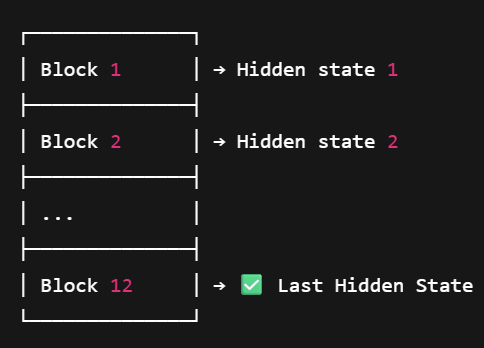

[Multi-head Attention] → [Add + Norm] → [Feedforward] → [Add + Norm]


#### **Example of AutoModelClass with Different heads**

| Task                        | Class Name                                          | Description                                          |
| --------------------------- | --------------------------------------------------- | ---------------------------------------------------- |
| Base Model               | `AutoModel`                                         | Just embeddings (no head), for feature extraction    |
| Masked LM                | `AutoModelForMaskedLM`                              | For BERT-style `[MASK]` prediction                   |
| Sequence Classification | `AutoModelForSequenceClassification`                | For sentence-level tasks like sentiment, spam        |
| Token Classification     | `AutoModelForTokenClassification`                   | For NER, POS tagging (token-level labels)            |
| Multiple Choice          | `AutoModelForMultipleChoice`                        | For MCQ tasks (e.g., SWAG dataset)                   |
| Next Sentence Prediction | `AutoModelForNextSentencePrediction`                | For NSP (mainly BERT pretraining)                    |
| Causal LM (Text Gen)     | `AutoModelForCausalLM`                              | For GPT-style models (left-to-right text generation) |
| Seq2Seq LM               | `AutoModelForSeq2SeqLM`                             | For translation, summarization (T5, BART)            |
| Question Answering       | `AutoModelForQuestionAnswering`                     | For extractive QA (SQuAD-style)                      |
| Vision Tasks            | `AutoModelForImageClassification`, etc.             | For image classification (e.g., ViT)                 |
| Audio Tasks              | `AutoModelForAudioClassification`, etc.             | For Wav2Vec, Whisper, etc.                           |
| Conditional Generation   | `AutoModelForConditionalGeneration`                 | For T5/BART-style seq2seq tasks                      |
| Zero-shot Tasks          | `AutoModelForZeroShotClassification` (via pipeline) | For inference without fine-tuning                    |
| Contrastive Learning     | `AutoModelForContrastiveLearning`                   | For embeddings comparison tasks                      |


In [68]:
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch

model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForMaskedLM.from_pretrained(model_name)

text = "Hello, how are [MASK]?"

inputs = tokenizer(text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

mask_index = torch.where(inputs["input_ids"][0] == tokenizer.mask_token_id)[0]
predicted_id = outputs.logits[0, mask_index].argmax(dim=-1)

print(tokenizer.decode(predicted_id))

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


you


In [69]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

prompt = "Explain reinforcement learning in simple words."

inputs = tokenizer(prompt, return_tensors="pt")

outputs = model.generate(
    **inputs,
    max_new_tokens=80,
    do_sample=True,
    temperature=0.7
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

[transformers] Both `max_new_tokens` (=80) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Explain reinforcement learning in simple words.


In [70]:
print(model)

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 2048)
    (layers): ModuleList(
      (0-21): 22 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (up_proj): Linear(in_features=2048, out_features=5632, bias=False)
          (down_proj): Linear(in_features=5632, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rot

In [71]:
print(model.config)
print("Layers:", model.config.num_hidden_layers)
print("Hidden size:", model.config.hidden_size)
print("Attention heads:", model.config.num_attention_heads)
print("Vocab size:", model.config.vocab_size)

LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 1,
  "dtype": "bfloat16",
  "eos_token_id": 2,
  "head_dim": 64,
  "hidden_act": "silu",
  "hidden_size": 2048,
  "initializer_range": 0.02,
  "intermediate_size": 5632,
  "max_position_embeddings": 2048,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 32,
  "num_hidden_layers": 22,
  "num_key_value_heads": 4,
  "pad_token_id": null,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-05,
  "rope_parameters": {
    "rope_theta": 10000.0,
    "rope_type": "default"
  },
  "tie_word_embeddings": false,
  "transformers_version": "5.12.1",
  "use_cache": true,
  "vocab_size": 32000
}

Layers: 22
Hidden size: 2048
Attention heads: 32
Vocab size: 32000


In [72]:
print(len(model.model.layers))

22


In [73]:
print(model.model.layers[0].self_attn)

LlamaAttention(
  (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
  (k_proj): Linear(in_features=2048, out_features=256, bias=False)
  (v_proj): Linear(in_features=2048, out_features=256, bias=False)
  (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
)


In [74]:
for i, layer in enumerate(model.model.layers):
    print(f"Layer {i}")
    print(layer.self_attn)
    print("-" * 50)

Layer 0
LlamaAttention(
  (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
  (k_proj): Linear(in_features=2048, out_features=256, bias=False)
  (v_proj): Linear(in_features=2048, out_features=256, bias=False)
  (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
)
--------------------------------------------------
Layer 1
LlamaAttention(
  (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
  (k_proj): Linear(in_features=2048, out_features=256, bias=False)
  (v_proj): Linear(in_features=2048, out_features=256, bias=False)
  (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
)
--------------------------------------------------
Layer 2
LlamaAttention(
  (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
  (k_proj): Linear(in_features=2048, out_features=256, bias=False)
  (v_proj): Linear(in_features=2048, out_features=256, bias=False)
  (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
)
----------

In [75]:
text = "Hello, how are you?"
inputs = tokenizer(text, return_tensors="pt")

print(inputs)
print(tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]))

{'input_ids': tensor([[    1, 15043, 29892,   920,   526,   366, 29973]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}
['<s>', '▁Hello', ',', '▁how', '▁are', '▁you', '?']


In [76]:
import torch

with torch.no_grad():
    outputs = model(**inputs)

print(outputs.keys())

odict_keys(['logits', 'past_key_values'])


In [77]:
print(outputs.logits.shape)

torch.Size([1, 7, 32000])


In [78]:
generated_ids = model.generate(
    **inputs,
    max_new_tokens=50
)

print(tokenizer.decode(generated_ids[0], skip_special_tokens=True))

[transformers] Both `max_new_tokens` (=50) and `max_length`(=2048) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Hello, how are you?

Jane:
(smiling)
I'm doing well, thank you.

Tom:
(smiling back)
Me too. How about you?

Jane:
(laughing)
I


In [79]:
with torch.no_grad():
    outputs = model(**inputs, output_hidden_states=True)

print(len(outputs.hidden_states))
print(outputs.hidden_states[-1].shape)

23
torch.Size([1, 7, 2048])


#### **Download model to storage disk**



In [80]:
from huggingface_hub import snapshot_download

local_dir_use_symlinks=True
→ Creates shortcuts that point to the original files.

local_dir_use_symlinks=False
→ Copies the actual files into the target folder.

In [81]:
snapshot_download(
    repo_id="bert-base-uncased",
    local_dir="/content/test",   # where to download
    local_dir_use_symlinks=False  # to copy instead of symlinking
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

'/content/test'